# General plume transmittance model fit demonstration

$ f(\lambda,\left(\boldsymbol\theta,\alpha\right)) = \left(\sum\limits_{i=0}^{N}\theta_{i}\lambda^{i}\right) e^{-\epsilon(\lambda)\alpha} $

In [1]:

#
# Test/demonstrate plume transimittance model curve fitting, based on
# demo_plume_pixel_pairing.ipynb results
#

import functools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import yaml

import pv


# data:
cfg_src = './config.yaml'
plume_data_src = './data/previous_manual_annotation_oneback.json'
cfg = yaml.safe_load(open(cfg_src))

# plume instance (also provides access to ch4 matched filter results):
plume = pv.emit_plume.EMITPlume(
    plume_id='CH4_PlumeComplex-3727',
    plume_data=plume_data_src,
    cfg=cfg)

# radiance data:
l1b_radiance = pv.emit_file.EMITAcquisitionFile(
    root=cfg['emit_acquisition_dataproducts_root'],
    id=plume.fid, level='l1b',
    type=cfg['emit_l1b_radiance_type'],
    ext='hdr')
wl = np.array(l1b_radiance.hdr['wavelength'],dtype=float)

# nominal target methane absorptivity data (note: these data bear no relation to
# the current plume, and are only being used here for test purposes in place of
# an actual call to ghg_process):
ch4_eps = pd.read_csv('./data/AV320241104t181131_target.csv',sep='\\s+',names=['index','lambda','eps'],header=None)
ch4_eps['eps'] *= -1.
# since these values have been provided on a slightly different wavelength grid,
# interpolate to EMIT spectra:
ch4_eps_interp = np.interp(wl,ch4_eps['lambda'],ch4_eps['eps'])

In [2]:
# retrieve paired target and background pixel radiances output from
# demo_plume_pairing.ipynb:
with open('demo_plume_pixel_pairing_target_radiances.npy','rb') as f:
    target_radiances = np.load(f)
with open('demo_plume_pixel_pairing_background_radiances.npy','rb') as f:
    background_radiances = np.load(f)

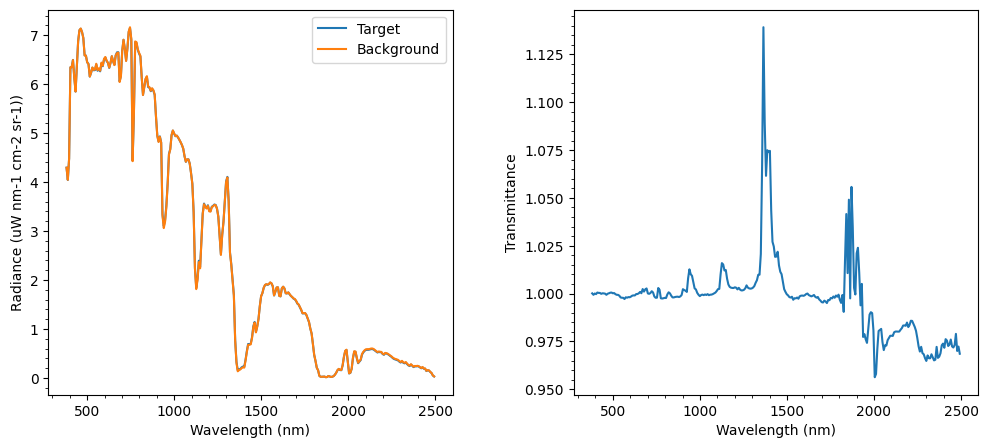

In [3]:
# Take a look at target and background radiances, and their ratio, which will be
# the subject of the transmittance model fit exercise:  
fig, axs = plt.subplots(1,2,figsize=(12,5))
axs[0].plot(wl,np.mean(target_radiances,axis=0),label='Target')
axs[0].plot(wl,np.mean(background_radiances,axis=0),label='Background')
axs[0].minorticks_on()
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Radiance (uW nm-1 cm-2 sr-1))')
axs[0].legend()
axs[0].minorticks_on()
target_background_radiance_ratio = \
    np.mean(target_radiances,axis=0)/np.mean(background_radiances,axis=0)
axs[1].plot(wl,target_background_radiance_ratio)
axs[1].minorticks_on()
axs[1].set_xlabel('Wavelength (nm)')
axs[1].set_ylabel('Transmittance')
plt.subplots_adjust(wspace=0.3,hspace=0.3)

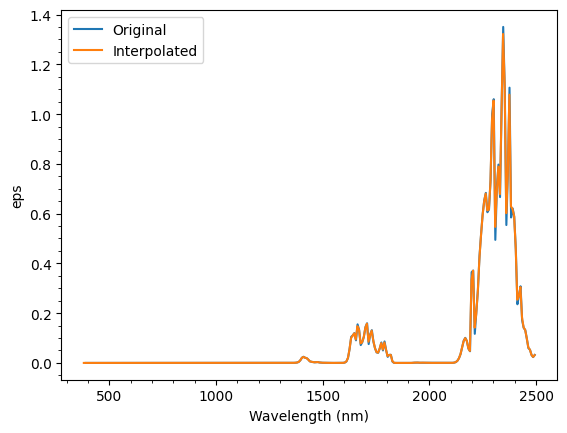

In [4]:
# Test target absorptivities are wavelenth-discretized on a slightly
# different grid than EMIT; interpolate, and plot, just to make sure:
fig, axs = plt.subplots()
# original:
axs.plot(ch4_eps['lambda'],ch4_eps['eps'],label='Original')
# interpolated:
ch4_eps
axs.plot(wl,ch4_eps_interp,label='Interpolated')
axs.minorticks_on()
axs.set_xlabel('Wavelength (nm)')
axs.set_ylabel('eps')
axs.legend()

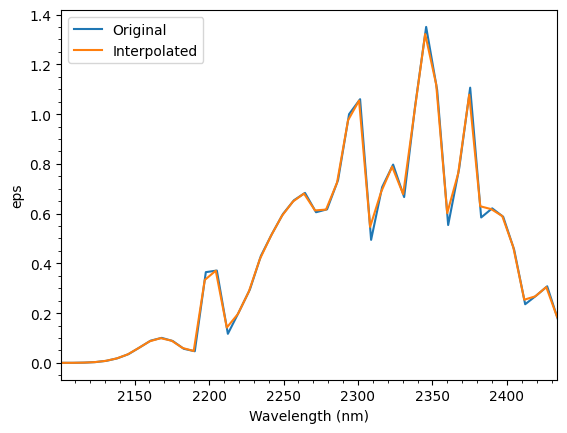

In [5]:
# same plot as above, but limited to ch4 model fitting range:
# ch4 wavelength indices for model fitting:
ch4_fitting_rngs = np.array(cfg['ch4_fitting_absorption_ranges'])
ch4_fitting_wl_indices = []
for i in range(ch4_fitting_rngs.shape[0]):
    ch4_fitting_wl_indices.extend(list(np.where((wl >= ch4_fitting_rngs[i,0]) & (wl <= ch4_fitting_rngs[i,1]))[0]))
# and, just to be sure, make sure none of the indices are repeated, and 
# sort for convenience:
ch4_fitting_wl_indices = list(set(ch4_fitting_wl_indices))
ch4_fitting_wl_indices.sort()
fig, axs = plt.subplots()
# original:
axs.plot(ch4_eps['lambda'],ch4_eps['eps'],label='Original')
# interpolated:
axs.plot(wl,ch4_eps_interp,label='Interpolated')
axs.set_xlim(wl[ch4_fitting_wl_indices[0]],wl[ch4_fitting_wl_indices[-1]])
axs.minorticks_on()
axs.set_xlabel('Wavelength (nm)')
axs.set_ylabel('eps')
axs.legend()

In [6]:
transmittance_model_fixed_epsilon = functools.partial(
    pv.utils.transmittance_model,epsilon=ch4_eps_interp[ch4_fitting_wl_indices])

In [7]:
popt, _ = curve_fit(
    transmittance_model_fixed_epsilon,
    wl[ch4_fitting_wl_indices],
    target_background_radiance_ratio[ch4_fitting_wl_indices],
    p0 = [1.,0.,0.,0.,0.,0.,0.,0.])

In [8]:
print(popt)

[ 7.31081103e-03 -7.51747057e-17  6.82011286e-13 -1.94364566e-09
  1.06131958e-07  9.53565427e-03 -1.73514304e+01  9.79748741e+03]


In [9]:
print(*popt)

0.007310811030733996 -7.517470574118689e-17 6.8201128645734e-13 -1.9436456577294356e-09 1.0613195753323559e-07 0.009535654271048964 -17.3514303547427 9797.487406883687


In [10]:
pv.utils.transmittance_model(
    wl[ch4_fitting_wl_indices],
    *popt,
    epsilon=ch4_eps_interp[ch4_fitting_wl_indices])

array([0.97871658, 0.97826424, 0.97834229, 0.97880733, 0.97952544,
       0.98037664, 0.98125859, 0.98207031, 0.98280563, 0.98352759,
       0.98425777, 0.98493921, 0.98529102, 0.98328665, 0.9828506 ,
       0.98411593, 0.98315011, 0.98174388, 0.97989567, 0.97819468,
       0.97648503, 0.97488007, 0.97343224, 0.97270121, 0.97151098,
       0.96965736, 0.966906  , 0.96551554, 0.96843896, 0.96696746,
       0.96597374, 0.96669227, 0.96457221, 0.9626583 , 0.9646289 ,
       0.96898797, 0.96867934, 0.9673337 , 0.97140645, 0.97230754,
       0.97315157, 0.97440045, 0.97585349, 0.9751372 , 0.97351706,
       0.9721045 ])

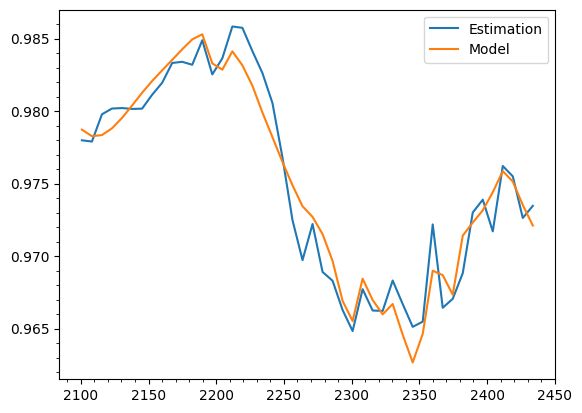

In [11]:
fig, axs = plt.subplots()
axs.plot(
    wl[ch4_fitting_wl_indices],
    target_background_radiance_ratio[ch4_fitting_wl_indices],
    label='Estimation')
axs.plot(
    wl[ch4_fitting_wl_indices],
    pv.utils.transmittance_model(
        wl[ch4_fitting_wl_indices],
        *popt,
        epsilon=ch4_eps_interp[ch4_fitting_wl_indices]),
    label='Model')
axs.minorticks_on()
axs.legend()